In [1]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
# import shutil
# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/working'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))



# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os

base_path = '/kaggle/input/datasets/aliasifkhan2105131/label-fault-merged-more/merged_classifier_dataset_without_aug'

# Dictionary to store folder names and their respective file counts
folder_counts = {}

# os.walk generates the file names in a directory tree
for root, dirs, files in os.walk(base_path):
    # Only count if there are files in the current folder
    if files:
        # Get the relative path from the base directory
        relative_path = os.path.relpath(root, base_path)
        folder_counts[relative_path] = len(files)

# Sort and print the results
print(f"{'Folder Name':<40} | {'File Count':<10}")
print("-" * 55)
total_files = 0
for folder, count in sorted(folder_counts.items()):
    print(f"{folder:<40} | {count:<10}")
    total_files += count

print("-" * 55)
print(f"{'TOTAL':<40} | {total_files:<10}")

Folder Name                              | File Count
-------------------------------------------------------
Cutting                                  | 414       
Folding                                  | 198       
Non_Faulty                               | 931       
Shade_color                              | 204       
Text_distortion                          | 84        
Weaving_Peak                             | 36        
Yarn_Missing                             | 16        
-------------------------------------------------------
TOTAL                                    | 1883      


In [3]:
import os
from PIL import Image
from collections import Counter

base_path = '/kaggle/input/datasets/aliasifkhan2105131/label-fault-merged-more/merged_classifier_dataset_without_aug'
size_counts = Counter()

# Valid image extensions
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tiff')

print("Scanning directory for image sizes...")

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.lower().endswith(valid_extensions):
            file_path = os.path.join(root, file)
            try:
                # opening the image does not load the data into memory, just the header
                with Image.open(file_path) as img:
                    size_counts[img.size] += 1
            except Exception:
                # Skip files that aren't actually images or are corrupted
                pass

# Display Summary Table
print(f"\n{'Resolution (W x H)':<25} | {'Count':<10}")
print("-" * 40)
for size, count in size_counts.most_common():
    print(f"{str(size):<25} | {count:<10}")

if not size_counts:
    print("No images found in the specified directory.")

Scanning directory for image sizes...

Resolution (W x H)        | Count     
----------------------------------------
(512, 512)                | 24        
(143, 71)                 | 4         
(75, 229)                 | 4         
(50, 199)                 | 3         
(50, 205)                 | 3         
(53, 199)                 | 3         
(149, 82)                 | 3         
(152, 78)                 | 3         
(72, 142)                 | 3         
(71, 205)                 | 3         
(72, 216)                 | 3         
(136, 70)                 | 3         
(76, 222)                 | 3         
(69, 213)                 | 3         
(69, 232)                 | 3         
(104, 175)                | 3         
(83, 463)                 | 3         
(86, 467)                 | 3         
(84, 455)                 | 3         
(83, 454)                 | 3         
(82, 453)                 | 3         
(50, 206)                 | 2         
(62, 214)              

In [4]:
import os
from PIL import Image
from collections import Counter

base_path = '/kaggle/input/datasets/aliasifkhan2105131/label-fault-merged-more/merged_classifier_dataset_without_aug'
stats = Counter()

print("Analyzing image modes...")

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(root, file)
            try:
                with Image.open(img_path) as img:
                    # img.mode 'L' is grayscale, 'RGB' is color, 'RGBA' is color+alpha
                    stats[img.mode] += 1
            except:
                stats['Corrupted/Error'] += 1

print("\n--- Image Mode Summary ---")
for mode, count in stats.items():
    readable_mode = {
        'L': 'Grayscale (1-channel)',
        'RGB': 'Color (3-channel)',
        'RGBA': 'Color + Transparency (4-channel)',
        'P': 'Palettized/Compressed'
    }.get(mode, mode)
    print(f"{readable_mode:<30}: {count}")

Analyzing image modes...

--- Image Mode Summary ---
Color (3-channel)             : 1883


In [5]:
import shutil
#run if needed to start from the start 
path="/kaggle/working/checkpoints"

try:
    shutil.rmtree(path)
except OSError as e:
    print(e.strerror)

No such file or directory


In [6]:
import torch 
import torch.nn as nn
import torch.optim as optim 
from torchvision import datasets , transforms , models
from torch.utils.data import DataLoader , Subset
import numpy as np
import os
import glob


In [7]:
from PIL import Image
from torchvision import transforms

class ResizePad:
    def __init__(self, size, fill=0):
        """
        size = (height, width)
        """
        self.target_h, self.target_w = size
        self.fill = fill

    def __call__(self, img):
        # PIL: img.size = (width, height)
        w, h = img.size

        scale = min(
            self.target_w / w,
            self.target_h / h
        )

        new_w = int(round(w * scale))
        new_h = int(round(h * scale))

        img = img.resize((new_w, new_h), Image.Resampling.BILINEAR)

        canvas = Image.new(
            img.mode,
            (self.target_w, self.target_h),
            color=self.fill
        )

        left = (self.target_w - new_w) // 2
        top = (self.target_h - new_h) // 2

        canvas.paste(img, (left, top))

        return canvas

In [8]:
from torchvision import transforms
TARGET_SIZE = (256, 640)

train_transform = transforms.Compose([

    transforms.Grayscale(num_output_channels=3),

    ResizePad(TARGET_SIZE),

    transforms.RandomRotation(5),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.03, 0.03),
        scale=(0.95, 1.05)
    ),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),

    transforms.RandomApply([
        transforms.GaussianBlur(3)
    ], p=0.2),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

val_transform = transforms.Compose([

    transforms.Grayscale(num_output_channels=3),

    ResizePad(TARGET_SIZE),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [9]:
# from torchvision import transforms

# # Since your images are already 224x224, we can focus on quality
# val_transform = transforms.Compose([
#     transforms.Grayscale(num_output_channels=3), # Ensure consistency
#     # Resize longest side to 224 while keeping aspect ratio
#     transforms.Resize(224),
#     # Pad to 224x224
#     transforms.Pad((0, 0, 0, 0)),  # explained below
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

# train_transform = transforms.Compose([
#     # 1. Convert to gray first to save computation on later steps
#     transforms.Grayscale(num_output_channels=3),
    
#     # 2. Geometry: simulate camera angles and slight tilt
#     transforms.RandomRotation(15),
#     transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
#     transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    
#     # 3. Surface Quality: simulate lighting and erosion
#     transforms.ColorJitter(brightness=0.3, contrast=0.3),
#     transforms.RandomApply([transforms.GaussianBlur(3)], p=0.3),
#     # Resize longest side to 224 while keeping aspect ratio
#     transforms.Resize(224),

#     # Pad to 224x224
#     transforms.Pad((0, 0, 0, 0)),  # explained below
#     # 4. Final Prep
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
# ])

In [10]:
#dataset loading and splitting 

data_dir="/kaggle/input/datasets/aliasifkhan2105131/label-fault-merged-more/merged_classifier_dataset_without_aug"
train_dataset_full=datasets.ImageFolder(root=data_dir,transform=train_transform)
val_dataset_full=datasets.ImageFolder(root=data_dir,transform=val_transform)
num_samples=len(train_dataset_full)
indices=np.random.permutation(num_samples)
split_index=int(.8*num_samples)
train_index,val_index=indices[:split_index],indices[split_index:]

train_dataset=Subset(train_dataset_full,train_index)
val_dataset=Subset(val_dataset_full,val_index)


print(f"Total images: {num_samples}")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

Total images: 1883
Training samples: 1506
Validation samples: 377


In [11]:
#
batch_size=32

train_loader=DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)
val_loader=DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)
print(batch_size)

32


In [12]:
import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(train_dataset_full.classes)

# 1. Load Model
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# 2. Freeze everything first
for param in model.parameters():
    param.requires_grad = False

# 3. Unfreeze specific layers for Hieroglyph feature extraction
# Unfreezing layer3 and 4 allows the model to learn complex strokes
for param in model.layer3.parameters():
    param.requires_grad = True
for param in model.layer4.parameters():
    param.requires_grad = True

# 4. Modify the Head (Final Layers)
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 512),
    nn.ReLU(),
    nn.Dropout(0.4), # High dropout is good for small-ish datasets
    nn.Linear(512, num_classes)
)
# Ensure the new head is also trainable
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

# 5. Loss & Optimizer
# Label smoothing helps if some hieroglyphs are hard to distinguish
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Differential Learning Rates: Lower for base layers, higher for the new head
optimizer = optim.Adam([
    {'params': model.layer3.parameters(), 'lr': 1e-5}, 
    {'params': model.layer4.parameters(), 'lr': 1e-4},
    {'params': model.fc.parameters(), 'lr': 1e-3}
])

epochs = 100
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

print(f"Model ready on {device}. Classes: {num_classes}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 231MB/s]


Model ready on cuda. Classes: 7


In [13]:
import copy

epochs = 100
checkpoint_dir = '/kaggle/working/checkpoints/resnet50'
os.makedirs(checkpoint_dir, exist_ok=True)

best_val_acc = 0.0
# We don't need best_model/best_optimizer variables if we save to disk immediately

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    epoch_train_acc = (correct_train / total_train) * 100
    epoch_train_loss = running_loss / len(train_loader.dataset)

    # --- VALIDATION PHASE ---
    model.eval()
    val_loss, correct_val, total_val = 0.0, 0, 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    epoch_val_acc = (correct_val / total_val) * 100
    epoch_val_loss = val_loss / len(val_loader.dataset)
    
    scheduler.step() # Update LR after each epoch
    
    print(f"Epoch [{epoch+1}/{epochs}] | Train Acc: {epoch_train_acc:.2f}% | Val Acc: {epoch_val_acc:.2f}%")

    # --- SAVE BEST MODEL LOGIC ---
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        save_path = os.path.join(checkpoint_dir, "best_model.pth")
        
        # Save immediately so we don't lose progress if the session ends
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_acc': best_val_acc,
        }, save_path)
        print(f"--> New Best Model Saved (Acc: {best_val_acc:.2f}%)")

    # --- PERIODIC SAVE (Optional) ---
    if (epoch + 1) % 10 == 0:
        torch.save(model.state_dict(), f"{checkpoint_dir}/model_epoch_{epoch+1}.pth")

Epoch [1/100] | Train Acc: 60.49% | Val Acc: 80.11%
--> New Best Model Saved (Acc: 80.11%)
Epoch [2/100] | Train Acc: 76.83% | Val Acc: 79.31%
Epoch [3/100] | Train Acc: 81.54% | Val Acc: 81.43%
--> New Best Model Saved (Acc: 81.43%)
Epoch [4/100] | Train Acc: 82.54% | Val Acc: 84.62%
--> New Best Model Saved (Acc: 84.62%)
Epoch [5/100] | Train Acc: 86.06% | Val Acc: 87.53%
--> New Best Model Saved (Acc: 87.53%)
Epoch [6/100] | Train Acc: 85.79% | Val Acc: 85.15%
Epoch [7/100] | Train Acc: 86.99% | Val Acc: 86.47%
Epoch [8/100] | Train Acc: 86.99% | Val Acc: 82.76%
Epoch [9/100] | Train Acc: 88.84% | Val Acc: 87.53%
Epoch [10/100] | Train Acc: 88.38% | Val Acc: 85.15%
Epoch [11/100] | Train Acc: 88.58% | Val Acc: 87.53%
Epoch [12/100] | Train Acc: 89.64% | Val Acc: 88.86%
--> New Best Model Saved (Acc: 88.86%)
Epoch [13/100] | Train Acc: 88.51% | Val Acc: 85.68%
Epoch [14/100] | Train Acc: 89.91% | Val Acc: 88.33%
Epoch [15/100] | Train Acc: 90.31% | Val Acc: 89.12%
--> New Best Model 

In [14]:
import os
import torch
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    cohen_kappa_score,
    classification_report
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# Load best checkpoint
# -----------------------------
checkpoint = torch.load(
    "/kaggle/working/checkpoints/resnet50/best_model.pth",
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

preds = []
labels = []
probs = []
paths = []

subset = val_loader.dataset          # Subset
base_dataset = subset.dataset        # ImageFolder

with torch.no_grad():

    idx_global = 0

    for images, target in val_loader:

        images = images.to(device)

        outputs = model(images)

        p = torch.softmax(outputs, dim=1)

        conf, pred = torch.max(p,1)

        preds.extend(pred.cpu().numpy())
        labels.extend(target.numpy())
        probs.extend(conf.cpu().numpy())

        bs = len(target)

        for i in range(bs):
            real_index = subset.indices[idx_global]
            paths.append(base_dataset.samples[real_index][0])
            idx_global += 1

preds=np.array(preds)
labels=np.array(labels)

results=pd.DataFrame({
    "path":paths,
    "gt":labels,
    "pred":preds,
    "confidence":probs
})

results.to_csv("predictions.csv",index=False)

print(results.head())

                                                path  gt  pred  confidence
0  /kaggle/input/datasets/aliasifkhan2105131/labe...   1     1    0.897475
1  /kaggle/input/datasets/aliasifkhan2105131/labe...   3     3    0.968944
2  /kaggle/input/datasets/aliasifkhan2105131/labe...   0     0    0.892345
3  /kaggle/input/datasets/aliasifkhan2105131/labe...   2     2    0.941771
4  /kaggle/input/datasets/aliasifkhan2105131/labe...   2     2    0.949071


In [15]:
from sklearn.metrics import *

print("="*50)

print("Accuracy:",
      accuracy_score(labels,preds))

print("Balanced Accuracy:",
      balanced_accuracy_score(labels,preds))

print("Precision:",
      precision_score(labels,preds,average="weighted"))

print("Recall:",
      recall_score(labels,preds,average="weighted"))

print("F1:",
      f1_score(labels,preds,average="weighted"))

print("MCC:",
      matthews_corrcoef(labels,preds))

print("Cohen Kappa:",
      cohen_kappa_score(labels,preds))

# Create a list of all possible class indices (0 to 5)
all_class_indices = list(range(len(train_dataset_full.classes)))

report=classification_report(
    labels,
    preds,
    labels=all_class_indices,
    target_names=train_dataset_full.classes,
    output_dict=True
)

pd.DataFrame(report).transpose().to_csv(
    "classification_report.csv"
)

Accuracy: 0.9124668435013262
Balanced Accuracy: 0.6799131421705299
Precision: 0.9126766307908885
Recall: 0.9124668435013262
F1: 0.907750304524596
MCC: 0.8665755637964634
Cohen Kappa: 0.8656276326874474


In [16]:
train_dataset_full.classes

['Cutting',
 'Folding',
 'Non_Faulty',
 'Shade_color',
 'Text_distortion',
 'Weaving_Peak',
 'Yarn_Missing']

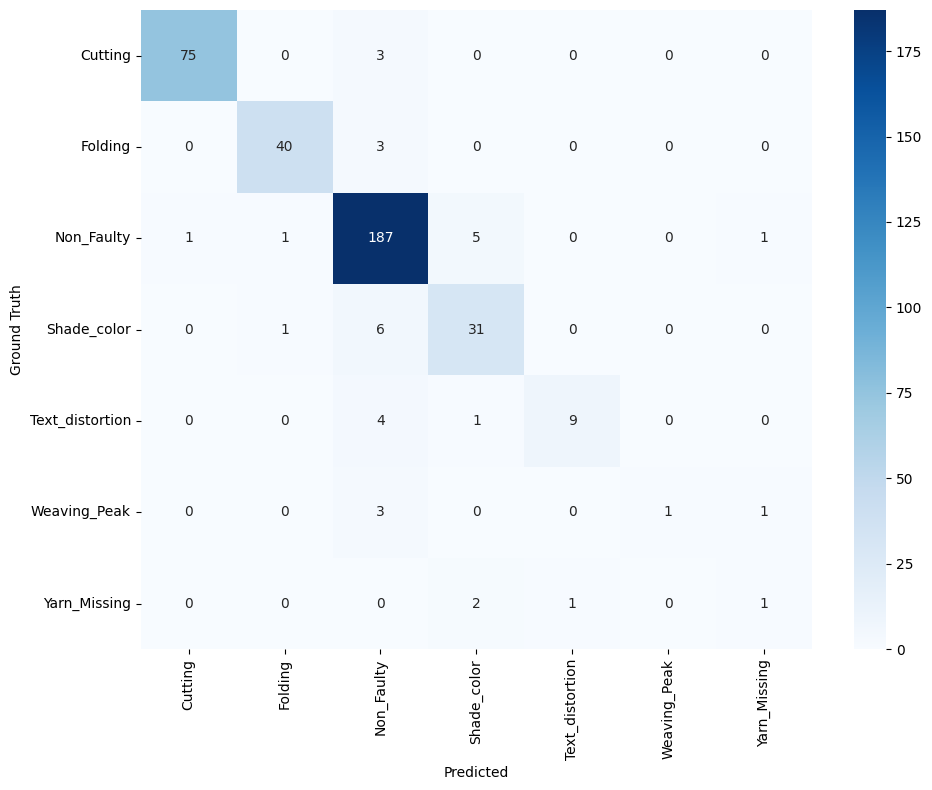

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm=confusion_matrix(labels,preds)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_dataset_full.classes,
    yticklabels=train_dataset_full.classes
)

plt.xlabel("Predicted")
plt.ylabel("Ground Truth")

plt.tight_layout()
plt.savefig("confusion_matrix.png",dpi=300)
plt.show()

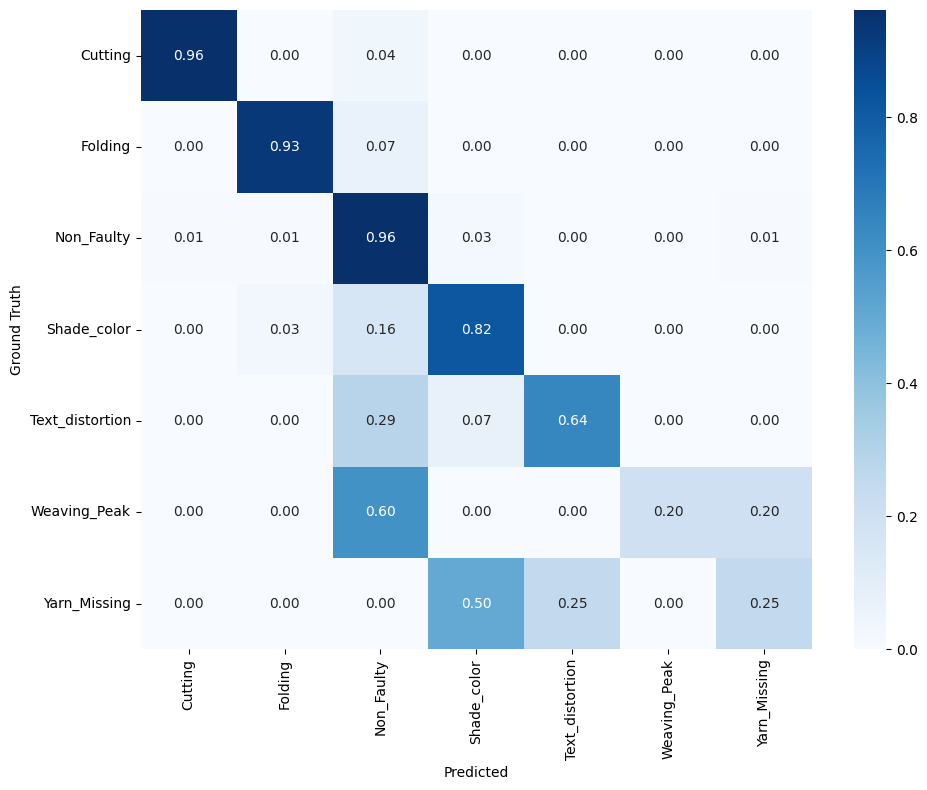

In [18]:
cm=confusion_matrix(labels,preds,normalize="true")

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    xticklabels=train_dataset_full.classes,
    yticklabels=train_dataset_full.classes
)

plt.xlabel("Predicted")
plt.ylabel("Ground Truth")

plt.tight_layout()
plt.savefig("confusion_matrix_normalized.png",dpi=300)
plt.show()

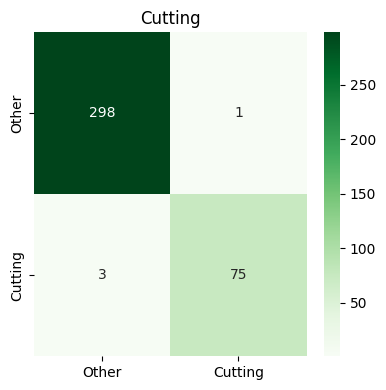

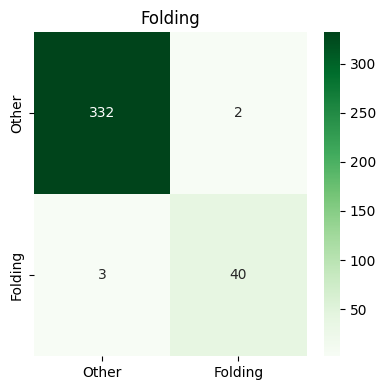

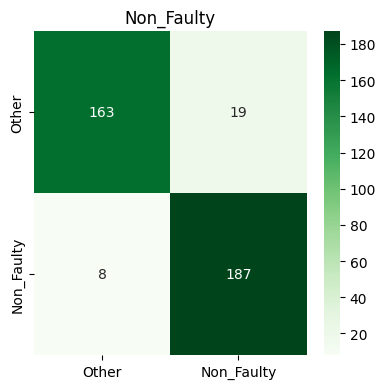

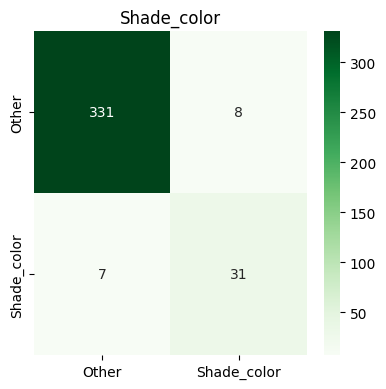

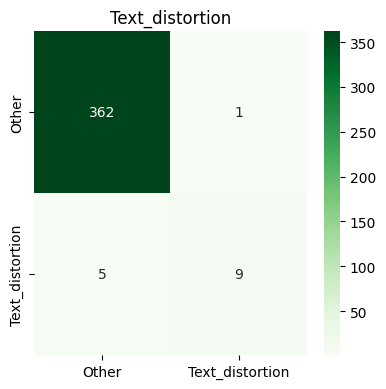

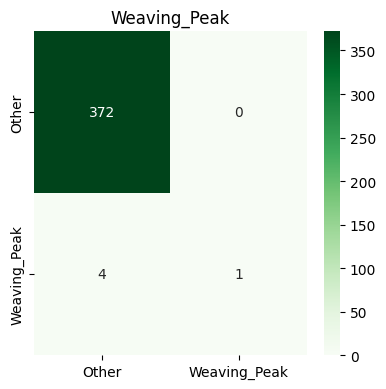

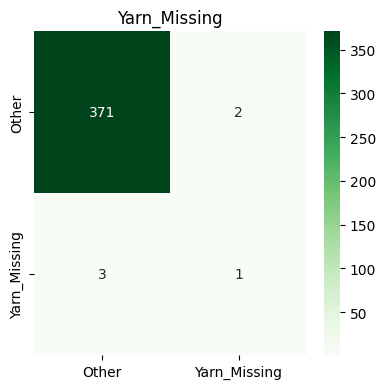

In [19]:
from sklearn.metrics import confusion_matrix

os.makedirs("binary_cm",exist_ok=True)

for c,name in enumerate(train_dataset_full.classes):

    gt=(labels==c).astype(int)
    pr=(preds==c).astype(int)

    cm=confusion_matrix(gt,pr)

    plt.figure(figsize=(4,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Greens",
        xticklabels=["Other",name],
        yticklabels=["Other",name]
    )

    plt.title(name)

    plt.tight_layout()

    plt.savefig(f"binary_cm/{name}.png",dpi=300)
    plt.show()
    plt.close()

In [20]:
import shutil

base="examples"

os.makedirs(base,exist_ok=True)

for c,name in enumerate(train_dataset_full.classes):

    for t in ["TP","FP","FN","TN"]:
        os.makedirs(f"{base}/{name}/{t}",exist_ok=True)

for i,row in results.iterrows():

    gt=row['gt']
    pred=row.pred

    name=train_dataset_full.classes[gt]

    if gt==pred:

        folder="TP"

    else:

        folder="FN"

        pred_name=train_dataset_full.classes[pred]

        shutil.copy(
            row.path,
            f"{base}/{pred_name}/FP/{os.path.basename(row.path)}"
        )

    shutil.copy(
        row.path,
        f"{base}/{name}/{folder}/{os.path.basename(row.path)}"
    )

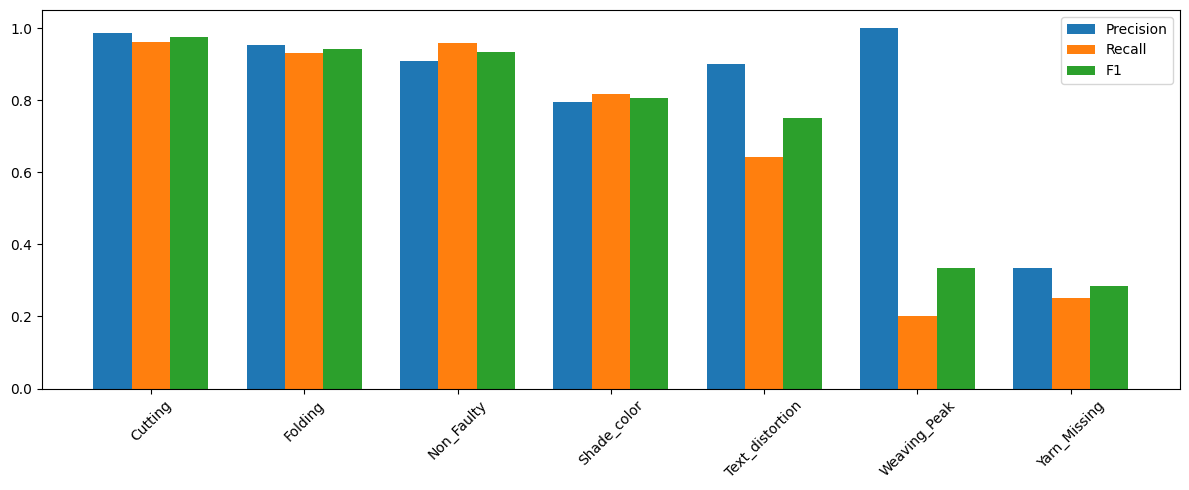

In [21]:
from sklearn.metrics import classification_report

report=classification_report(
    labels,
    preds,
    labels=all_class_indices,
    target_names=train_dataset_full.classes,
    output_dict=True
)

df=pd.DataFrame(report).transpose()

df=df.iloc[:-3]

plt.figure(figsize=(12,5))

x=np.arange(len(df))

plt.bar(x-0.25,df.precision,width=0.25,label="Precision")
plt.bar(x,df.recall,width=0.25,label="Recall")
plt.bar(x+0.25,df["f1-score"],width=0.25,label="F1")

plt.xticks(x,df.index,rotation=45)

plt.legend()

plt.tight_layout()

plt.savefig("metrics.png",dpi=300)

plt.show()

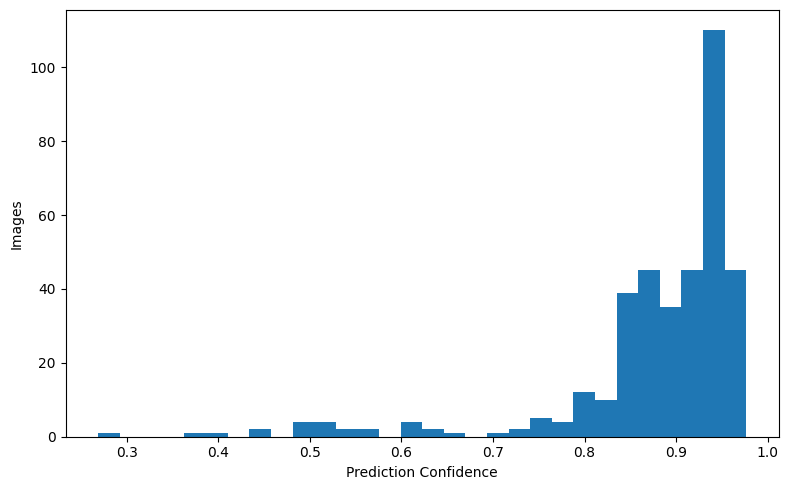

In [22]:
plt.figure(figsize=(8,5))

plt.hist(results.confidence,bins=30)

plt.xlabel("Prediction Confidence")

plt.ylabel("Images")

plt.tight_layout()

plt.savefig("confidence_histogram.png",dpi=300)

plt.show()

In [23]:
import os
import shutil
import pandas as pd

os.makedirs("hardest_mistakes", exist_ok=True)

# Wrong predictions only
mistakes = results[results["gt"] != results["pred"]].copy()

# Highest confidence wrong predictions
mistakes = mistakes.sort_values("confidence", ascending=False)

TOP_K = 20
hardest = mistakes.head(TOP_K)

hardest.to_csv("hardest_mistakes.csv", index=False)

for idx, row in hardest.iterrows():

    gt_name = train_dataset_full.classes[int(row["gt"])]
    pred_name = train_dataset_full.classes[int(row["pred"])]

    filename = (
        f"GT_{gt_name}"
        f"__PRED_{pred_name}"
        f"__CONF_{row['confidence']:.3f}"
        f"__{os.path.basename(row['path'])}"
    )

    shutil.copy(
        row["path"],
        os.path.join("hardest_mistakes", filename)
    )

print("Saved", len(hardest), "hardest mistakes.")

Saved 20 hardest mistakes.


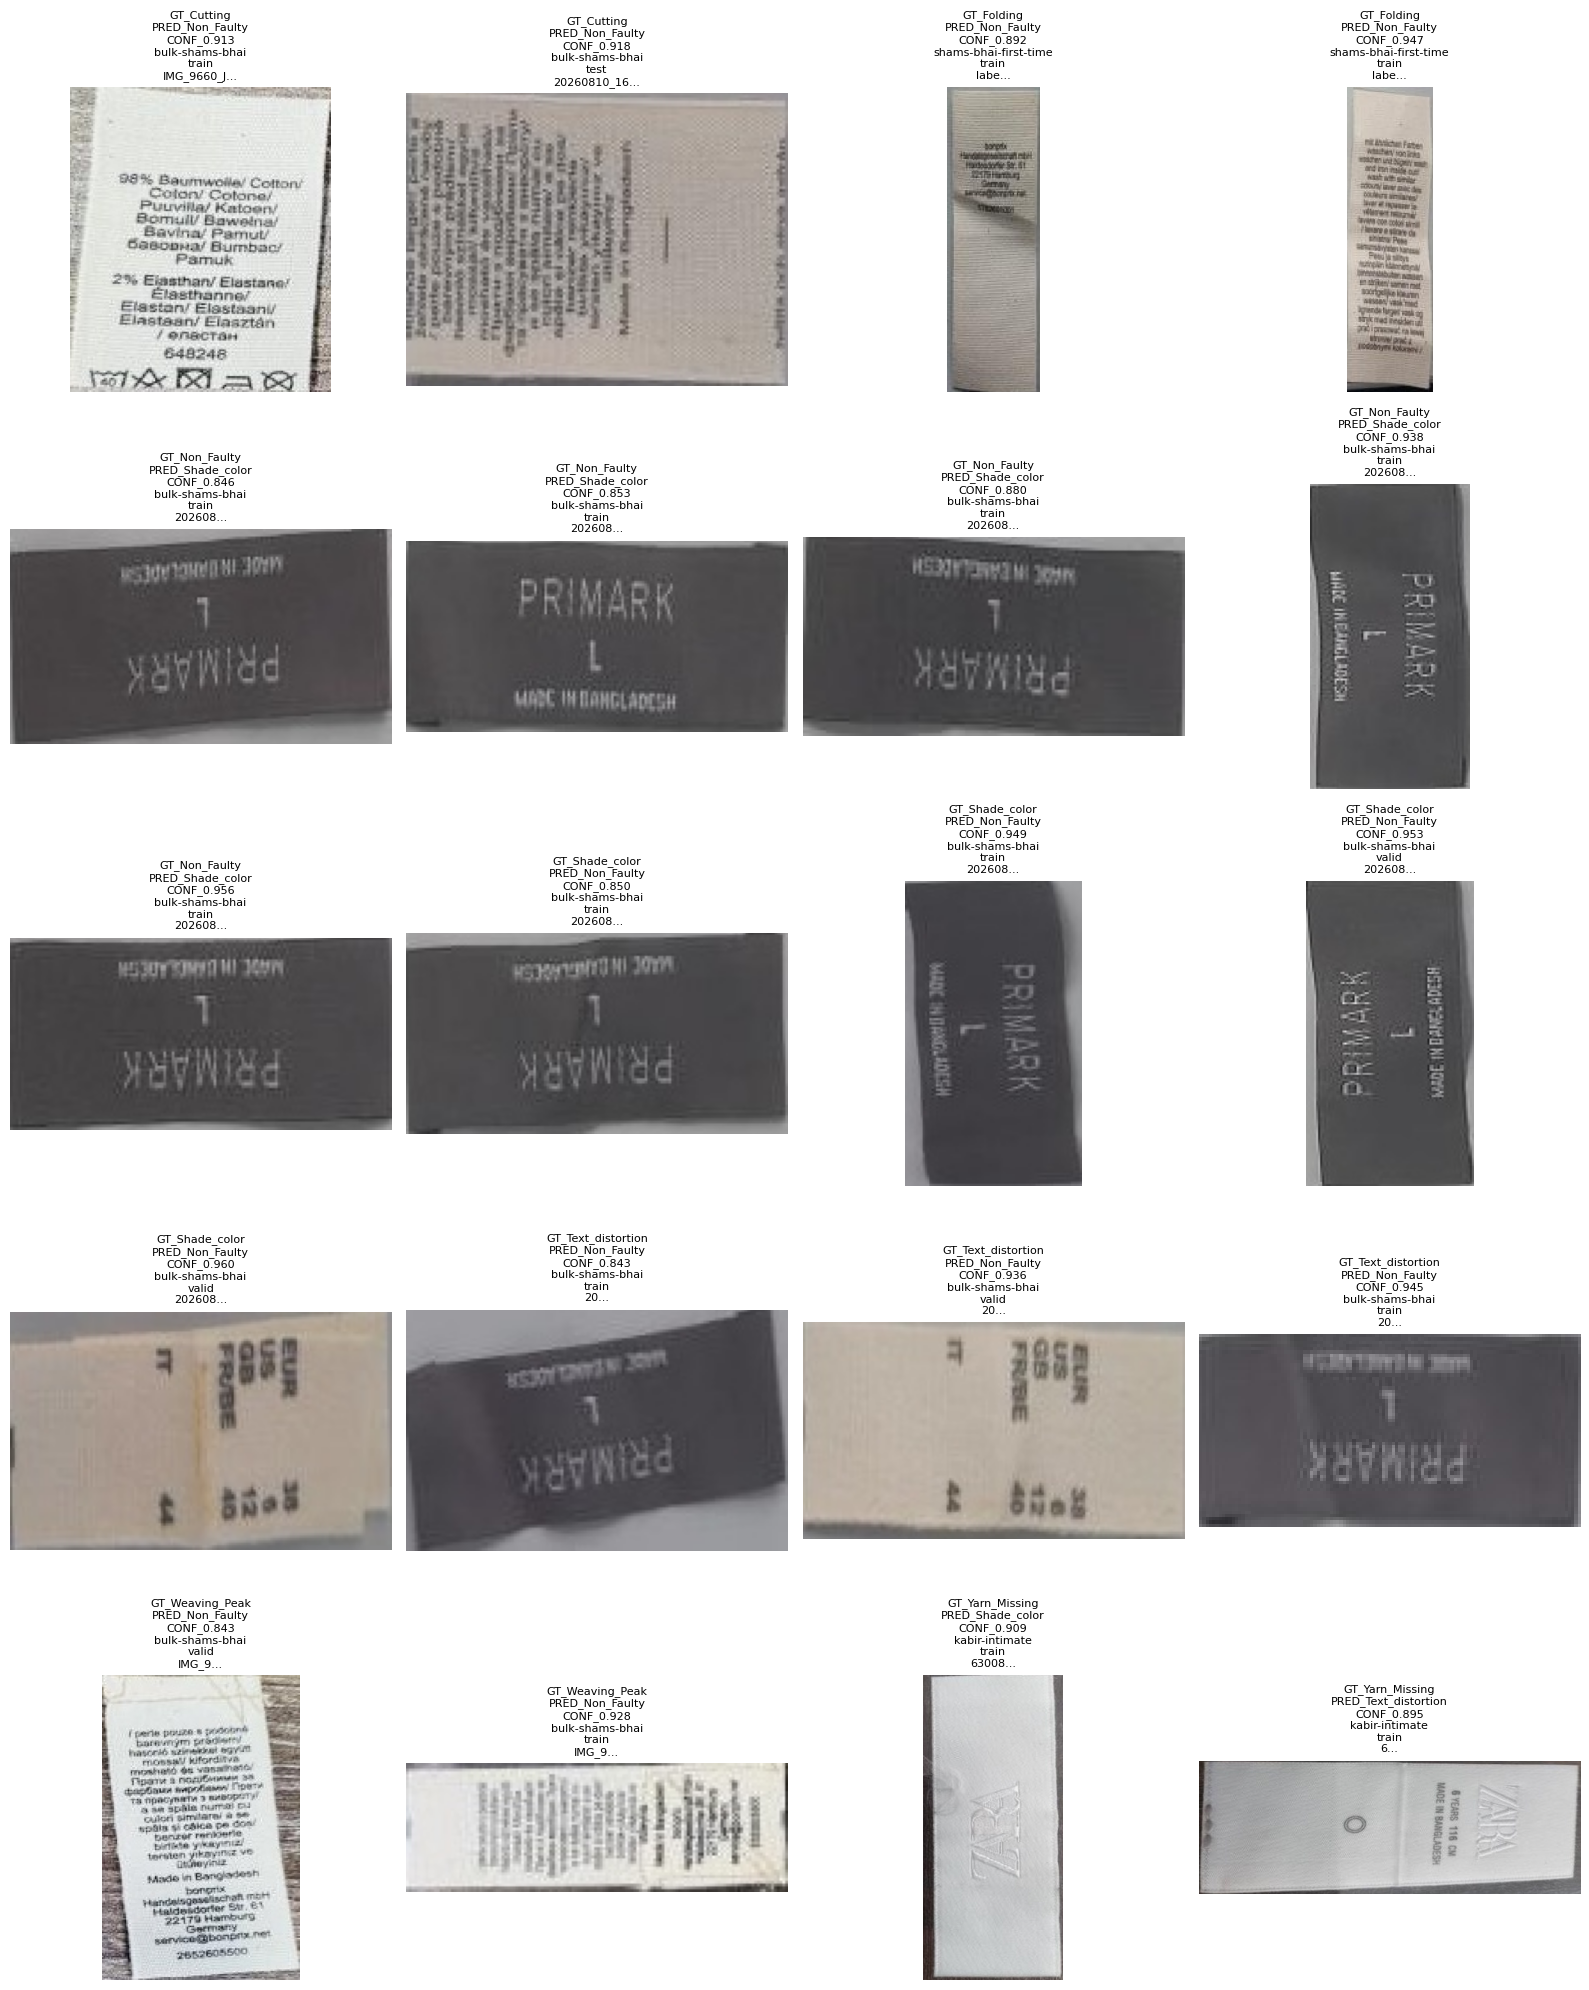

In [24]:
from PIL import Image
import matplotlib.pyplot as plt
import math
import os

files = sorted(os.listdir("hardest_mistakes"))

n = len(files)
cols = 4
rows = math.ceil(n / cols)

plt.figure(figsize=(16, 4 * rows))

for i, f in enumerate(files):

    img = Image.open(os.path.join("hardest_mistakes", f))

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis("off")

    title = f.replace("__", "\n")
    if len(title) > 70:
        title = title[:70] + "..."

    plt.title(title, fontsize=8)

plt.tight_layout()
plt.savefig("hardest_mistakes_summary.png", dpi=300)
plt.show()

In [25]:
import shutil

os.makedirs("evaluation_results",exist_ok=True)

files=[
    "predictions.csv",
    "classification_report.csv",
    "metrics.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "confidence_histogram.png"
]

for f in files:
    shutil.copy(f,"evaluation_results")

shutil.copytree(
    "binary_cm",
    "evaluation_results/binary_cm",
    dirs_exist_ok=True
)

shutil.copytree(
    "examples",
    "evaluation_results/examples",
    dirs_exist_ok=True
)

shutil.make_archive(
    "evaluation_results",
    "zip",
    "evaluation_results"
)

print("Done!")

Done!


In [26]:
shutil.copy(
    "hardest_mistakes.csv",
    "evaluation_results"
)

shutil.copy(
    "hardest_mistakes_summary.png",
    "evaluation_results"
)

shutil.copytree(
    "hardest_mistakes",
    "evaluation_results/hardest_mistakes",
    dirs_exist_ok=True
)

'evaluation_results/hardest_mistakes'